# RK2.VS.Leap-Frog.VS.Verlet

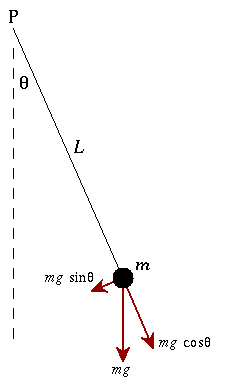

In [1]:
from IPython.display import Image
Image("nonLinearPendulum.gif")

### Péndulo no lineal
El desplazamiento del brazo en la posición vertical está dado en términos de $\theta$ y su dirección tangencial es $l\frac{d^2\theta}{dt^2}$.

$$
ml\frac{d^2\theta}{dt^2} = -mg sin(\theta)
$$

$$
\frac{d^2\theta}{dt^2} = -\frac{g}{l} sin(\theta)
$$

Expresando la ecuación de segundo órden como dos ecuaciones diferenciales de primer órden.

$$
\frac{d\theta}{dt} = \omega
$$

$$
\frac{d\omega}{dt} = -\frac{g}{l}sin\theta
$$


### Ejercicio

Escribir la expresion para la energía en términos de los parametros del péndulo:

Primero, la energía cinética está dada por:

\begin{equation}
    T=\frac{1}{2}mv^2=\frac{1}{2}m(l\omega)^2=\frac{1}{2}ml^2\omega^2
\end{equation}

Por otro lado, la energía potencial viene dada por:

\begin{equation}
    U=mgl(1-cos\theta)
\end{equation}

por lo que la energía total será:

\begin{equation}
    E=T+U=\frac{1}{2}ml^2\omega^2-mgl(1-cos\theta)
\end{equation}

### Ejercicio

Generaliza la expresión de la energía inicial en todos los códigos

## RK2

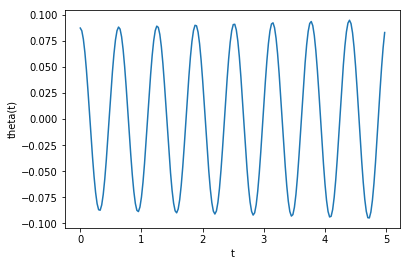

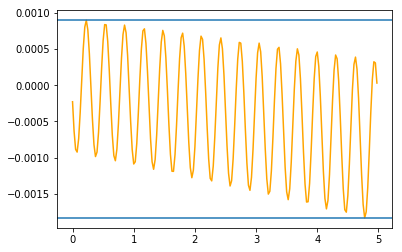

In [7]:
#Runge-Kutta orden 2 pendulo
from pylab import *
g=9.81
l=0.1
def f(r,t):
    theta=r[0]
    omega=r[1]
    ftheta=omega
    fomega=(-g/l)*sin(theta)
    return array([ftheta,fomega],float)

a = 0.0
b = 5.0
N = 200
h = (b-a)/N

lista_t = arange(a,b,h)
lista_theta = []
lista_omega = []

#r = array([179/180*pi,0],float)
r = array([5/180*pi,0],float)
for t in lista_t:
    lista_theta.append(r[0])
    k1=h*f(r,t)
    k2=h*f(r+0.5*k1,t+0.5*h)
    r+=k2
    lista_omega.append(r[1])

plot(lista_t,lista_theta)
xlabel('t')
ylabel('theta(t)')
show()

E=[]
m=1
inicial_0=0.5*m*(l*lista_omega[0])**2+m*g*l*(1-cos(lista_theta[0]))

for i in range(len(lista_t)):
    cinetica=(m*(l**2)*(lista_omega[i])**2)/(2)
    potencial=m*g*l*(1-cos(lista_theta[i]))
    energia=inicial_0-(cinetica+potencial)
    E.append(energia)

dE_max=(max(E))
dE_min=(min(E))
plot(lista_t,E,'orange')
axhline(y=dE_max)
axhline(y=dE_min)
show()


## Leap-Frog

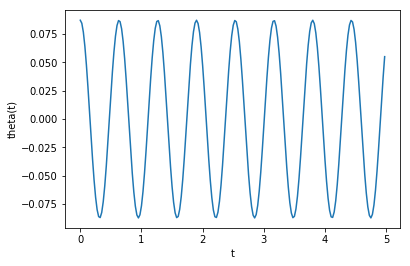

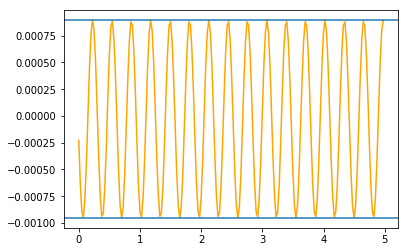

In [3]:
#Solución de Leap-Frog
from pylab import *

g=9.81
l=0.1
def f(r,t):
    theta=r[0]
    omega=r[1]
    ftheta=omega
    fomega=(-g/l)*sin(theta)
    return array([ftheta,fomega],float)

a = 0.0
b = 5.0
N = 200
h = (b-a)/N

lista_t = arange(a,b,h)
lista_theta = []
lista_omega = []

#r = array([179/180*pi,0],float)
r = array([5/180*pi,0],float)
rH = r+0.5*h*f(r,0)
for t in lista_t:
    lista_theta.append(r[0])
    r+=h*f(rH,t+0.5*h)
    rH+=h*f(r,t+h)
    lista_omega.append(r[1])
    
plot(lista_t,lista_theta)
xlabel('t')
ylabel('theta(t)')
show()

E=[]
m=1
inicial_0=0.5*m*(l*lista_omega[0])**2+m*g*l*(1-cos(lista_theta[0]))

for i in range(len(lista_t)):
    cinetica=(m*(l**2)*(lista_omega[i])**2)/(2)
    potencial=m*g*l*(1-cos(lista_theta[i]))
    energia=inicial_0-(cinetica+potencial)
    E.append(energia)

    
dE_max=(max(E))
dE_min=(min(E))
plot(lista_t,E,'orange')
axhline(y=dE_max)
axhline(y=dE_min)
show()

## Verlet

Supongamos que queremos usar leapfrog para resolver ecuaciones clásicas de movimiento para un sistema físico dado. Si usamos podemos expresar la seguna ley de Newton de la siguiente forma:

$$
\frac{d^2x}{dt^2} = f(x,t)
$$

Luego convertimos este sistema de ecuaciones de movimiento a ecuaciones diferenciales acopladas de primer orden:

$$
\frac{dx}{dt}=v, \frac{dx}{dt}=f(x,t) 
$$

Usamos $v$ para recordar que hablamos de un sistema fîsico.

Ahora si tenemos $x$ a un tiempo $t$ y v a un tiempo $t+\frac{1}{2}h$. Entonces iterando sobre las siguientes expresiones:

$$
x(t+h) = x(t) + hv(t+\frac{1}{2}h)\\
v(t+\frac{3}{2}h)=v(t+\frac{1}{2}h)+hf(x(t+h), t+h)
$$

Obtenemos $x$ a cualquier tiempo que deseemos, y en consecuencia tambien la $t$ pero siempre desfasada un medio de $h$. Dependiendo del sistema y el tamaño del paso medir la energía con velocidad desfasada involucra una pequeña impresición. Para conocer energía a un tiempo determinado tenemos que realizar operaciones extras en la velocidad.

Digamos que si tenemos la velocidad a un tiempo $t+h$, simplemente hacemos un paso medio para atrás usando el método de Euler para tenerlo en el tiempo $t+\frac{1}{2}h$:

$$
v(t+\frac{1}{2}h) = v(t+h) - \frac{1}{2}h f(x(t+h),t+h)
$$

Reacomodando:

$$
v(t+h) = v(t+\frac{1}{2}h) + \frac{1}{2}h f(x(t+h),t+h)
$$

Lo cual nos permite saber en pasos enteros de $h$ la velocidad. De esta forma si conocemos los valores iniciales $x,v$ a algûn tiempo $t$ entonces:

$$
v(t+\frac{1}{2}h) = v(t) + \frac{1}{2}h f(x(t),t)
$$

Y a partir de ahí aplicamos de forma iterativa:

$$
x(t+h) = x(t) + hv(t+\frac{1}{2}h),\\
k=hf(x(t+h), t+h),\\
v(t+h) = v(t+\frac{1}{2}h)+\frac{1}{2}k,\\
v(t+\frac{3}{2}h) = v(t+\frac{1}{2}h)+k
$$



### Ejercicio

Generalizar a ecuaciones de movimiento en más de una dimensión.

Para más dimensiones, partimos de la ley de Newton espresada en forma vectorial:

\begin{equation}
    \frac{d^2\mathbf{r}}{dt^2}=\mathbf{F(r},t)
\end{equation}

Haciendo una correspondencia análoga con la velocidad:

$$
\frac{d\mathbf{r}}{dt}=\mathbf{v}, \frac{d\mathbf{v}}{dt}=\mathbf{F(r},t)
$$

El desarrollo matemático es análogo y se llega a las expresiones vectoriales:

$$
\mathbf{v}(t+\frac{1}{2}h)=\mathbf{v}(t)+\frac{1}{2}h\mathbf{F(r}(t),t),
$$

$$
\mathbf{r}(t+h)=\mathbf{r}(t)+h\mathbf{v}(t+\frac{1}{2}h),
$$

$$
\mathbf{k}=h\mathbf{F(r(}t+h),t+h),
$$

$$
\mathbf{v}(t+h)=\mathbf{v}(t+\frac{1}{2}h)+\frac{1}{2}\mathbf{k},
$$

$$
\mathbf{v}(t+\frac{3}{2}h)=\mathbf{v}(t+\frac{1}{2}h)+\mathbf{k}
$$

### Ejercicio

Agregar una gráfica del espacio fase usando multiples condiciones iniciales (cambia v!). Y describe el sistema.

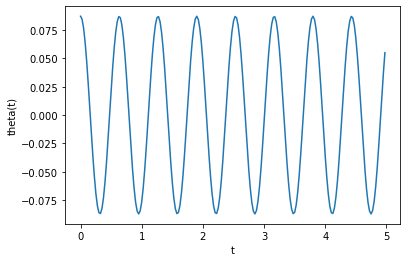

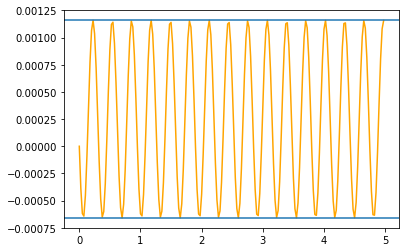

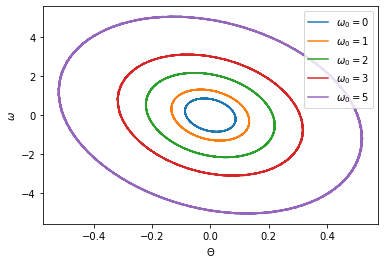

In [28]:
#Verlet
from pylab import *

g=9.81
l=0.1
def f(r,t):
    theta=r[0]
    omega=r[1]
    ftheta=omega
    fomega=(-g/l)*sin(theta)
    return array([ftheta,fomega],float)

a = 0.0
b = 5.0
N = 200
h = (b-a)/N

lista_t = arange(a,b,h)
lista_theta0 = []
lista_theta1=[]
lista_theta2=[]
lista_theta3=[]
lista_theta4=[]

lista_theta=[lista_theta0,lista_theta1,lista_theta2,lista_theta3,lista_theta4]

lista_omega0=[]
lista_omega1=[]
lista_omega2=[]
lista_omega3=[]
lista_omega4=[]

lista_omega=[lista_omega0,lista_omega1,lista_omega2,lista_omega3,lista_omega4]

r0 = [5/180*pi,0] #condiciones iniciales
r1 = [5/180*pi,1]
r2=[5/180*pi,2]
r3=[5/180*pi,3]
r4=[5/180*pi,5]

r=[r0,r1,r2,r3,r4]

for i in range(5):
    rH = r[i]+0.5*h*f(r[i],0) #inicio paso intermedio
    for t in lista_t:
        lista_theta[i].append(r[i][0])
        r[i]+=h*f(rH,t+0.5*h)
        k=h*f(r[i],t+h)
        v=rH+0.5*k
        rH+=h*f(r[i],t+h)
        lista_omega[i].append(v[1])
    
plot(lista_t,lista_theta[0])
xlabel('t')
ylabel('theta(t)')
show()

E=[]
m=1
inicial_0=0.5*m*(l*lista_omega[0][0])**2+m*g*l*(1-cos(lista_theta[0][0]))

for i in range(len(lista_t)):
    cinetica=(m*(l**2)*(lista_omega[0][i])**2)/(2)
    potencial=m*g*l*(1-cos(lista_theta[0][i]))
    energia=inicial_0-(cinetica+potencial)
    E.append(energia)

dE_max=(max(E))
dE_min=(min(E))
plot(lista_t,E,'orange')
axhline(y=dE_max)
axhline(y=dE_min)
show()

plot(lista_theta[0],lista_omega[0],label='$\omega_0=0$')
plot(lista_theta[1],lista_omega[1],label='$\omega_0=1$')
plot(lista_theta[2],lista_omega[2],label='$\omega_0=2$')
plot(lista_theta[3],lista_omega[3],label='$\omega_0=3$')
plot(lista_theta[4],lista_omega[4],label='$\omega_0=5$')
xlabel('$\Theta$')
ylabel('$\omega$')
legend()

show()

In [14]:
a=[0,1]
b=[2,3]
c=[a,b]
c[0].append(1)
print(c[0][0])

0


## Reversibilidad temporal

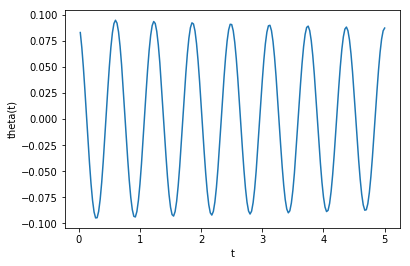

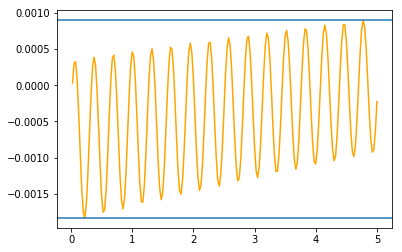

In [5]:
#Runge-Kutta orden 2 pendulo
from pylab import *
g=9.81
l=0.1
def f(r,t):
    theta=r[0]
    omega=r[1]
    ftheta=omega
    fomega=(-g/l)*sin(theta)
    return array([ftheta,fomega],float)

a = 0.0
b = 5.0
N = 200
h = (b-a)/N

lista_t = arange(b,a,-h)
lista_theta = []
lista_omega = []

#r = array([179/180*pi,0],float)
r = array([5/180*pi,0],float)

for t in lista_t:
    lista_theta.append(r[0])
    k1=-h*f(r,t)
    k2=-h*f(r+0.5*k1,t-0.5*h)
    r+=k2
    lista_omega.append(r[1])

plot(lista_t,lista_theta)
xlabel('t')
ylabel('theta(t)')
show()

E=[]
m=1
inicial_0=0.5*m*(l*lista_omega[0][0])**2+m*g*l*(1-cos(lista_theta[0]))

for i in range(len(lista_t)):
    cinetica=(m*(l**2)*(lista_omega[i])**2)/(2)
    potencial=m*g*l*(1-cos(lista_theta[i]))
    energia=inicial_0-(cinetica+potencial)
    E.append(energia)

dE_max=(max(E))
dE_min=(min(E))
plot(lista_t,E,'orange')
axhline(y=dE_max)
axhline(y=dE_min)
show()


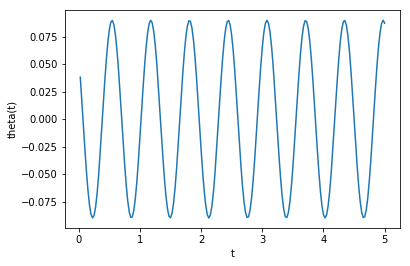

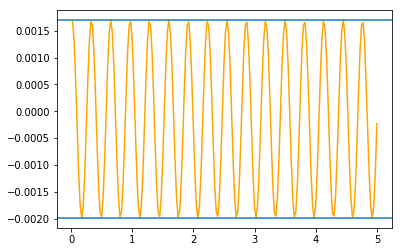

In [6]:
#Solución de Leap-Frog
from pylab import *

g=9.81
l=0.1
def f(r,t):
    theta=r[0]
    omega=r[1]
    ftheta=omega
    fomega=(-g/l)*sin(theta)
    return array([ftheta,fomega],float)

a = 0.0
b = 5.0
N = 200 
h = (b-a)/N

lista_t = arange(b,a,-h)
lista_theta = []
lista_omega = []

#r = array([179/180*pi,0],float)
r = array([5/180*pi,0],float)
rH = r+0.5*h*f(r,0)
for t in lista_t:
    lista_theta.append(r[0])
    r-=h*f(rH,t-0.5*h)
    rH-=h*f(r,t-h)
    lista_omega.append(r[1])
    
plot(lista_t,lista_theta)
xlabel('t')
ylabel('theta(t)')
show()

E=[]
m=1
inicial_0=0.5*m*(l*lista_omega[0][0])**2+m*g*l*(1-cos(lista_theta[0]))

for i in range(len(lista_t)):
    cinetica=(m*(l**2)*(lista_omega[i])**2)/(2)
    potencial=m*g*l*(1-cos(lista_theta[i]))
    energia=inicial_0-(cinetica+potencial)
    E.append(energia)

    
dE_max=(max(E))
dE_min=(min(E))
plot(lista_t,E,'orange')
axhline(y=dE_max)
axhline(y=dE_min)
show()

### Ejercicio
Orbita de la tierra alrededor del sol.

1) Investiga los parámetros relevantes para el sistema tierra sol.

2) Establece la ecuación diferencial vectorial ($\mathbf{r}=(x,y)$) de segundo orden para este sistema.

3) Resuelve numéricamente, usando Verlet, el sistema tierra sol calculando la orbita de la tierra (usa pasos de una hora)

4) Grafica la energía total en función del tiempo.

Usando la ecuación de la Ley de Gravitación Universal de Newton para modelar la atracción gravitatoria entre el Sol y la Tierra, podemos escrobir la Segunda Ley de Newton para la Tierra como:

$$
m\frac{d^2\mathbf{r}}{dt^2}=-G\frac{mM}{r^2}\mathbf{\hat{r}}
$$

$$
\frac{d^2\mathbf{r}}{dt^2}=-G\frac{M}{r^2}\mathbf{\hat{r}}
$$

Convertimos esta ecuación de segundo orden en un sistema de dos ecuaciones de primer orden:

$$
\frac{d\mathbf{r}}{dt}=\mathbf{v}, \frac{d\mathbf{v}}{dt}=-G\frac{M}{r^2}\mathbf{\hat{r}}
$$

Fijando nuestro sistema de coordenadas con el origen sobre el Sol tal que $\mathbf{r}=(x,y)$ es la posicón de la Tierra respecto al Sol. Con esto, se tendría que $r=\sqrt(x^2+y^2)$ y $\mathbf{\hat{r}}=\frac{\mathbf{r}}{r}$. Con esto, podemos escribir las ecuaciones como:

$$
\frac{dx}{dt}=v_x, \frac{dv_x}{dt}=-G\frac{Mx}{(x^2+y^2)^{3/2}}
$$

$$
\frac{dy}{dt}=v_y, \frac{dv_y}{dt}=-G\frac{My}{(x^2+y^2)^{3/2}}
$$

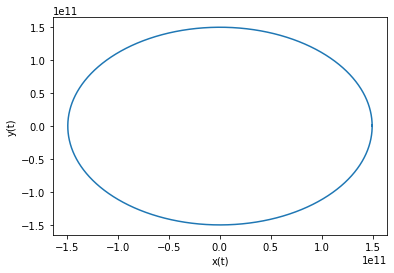

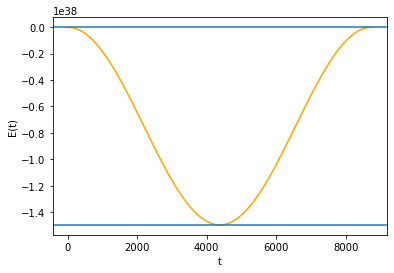

In [10]:
from pylab import *

M=1.989e30  #Masa del Sol
m=5.972e24  #Masa de la Tierra

ph=149.59e9 #Unidad astronómica
vh=107236341.72 #Velocidad promedio de la Tierra alrededor del Sol (La usaremos como condición inicial)
G=4*pi**2*ph**3/(8760**2*M)  #Constante de Gravitación Universal, de acuerdo a la Tercera Ley de Kepler; el periodo lo tomamos en horas 1 año=8760 horas
K=G*M

def f(r,t):
    x=r[0]
    vx=r[2]
    y=r[1]
    vy=r[3]
    fx=vx
    fvx=-(K*x/(x**2+y**2)**(3/2))
    fy=vy
    fvy=-(K*y/(x**2+y**2)**(3/2))
    
    return array([fx,fy,fvx,fvy],float)

lista_x=[]
lista_vx=[]
lista_y=[]
lista_vy=[]

a=0.0
b=8760 #En un año hay 8760 horas
N=8760
h=(b-a)/N

lista_t=arange(a,b,h)

r=array([ph,0,0,vh],float)

inicial_0=0.5*(m*(r[2]**2+r[3]**2))-(G*M/ph)


rH=r+0.5*h*f(r,0)

for t in lista_t:
    lista_x.append(r[0])
    lista_y.append(r[1])
    r+=h*f(rH,t+0.5*h)
    k=h*f(r,t+h)
    v=rH+0.5*k
    rH+=h*f(r,t+h)
    lista_vx.append(v[2])
    lista_vy.append(v[3])
    
E=[]    

for i in range(len(lista_t)):
    cinetica=(m*(lista_vx[i]**2+lista_vy[i]**2))/(2)
    potencial=-(G*M/sqrt(lista_x[i]**2+lista_y[i]**2))
    energia=inicial_0-(cinetica+potencial)
    E.append(energia)
    
#plot(lista_t,lista_x)
#plot(lista_t,lista_y)
plot(lista_x,lista_y)
xlabel('x(t)')
ylabel('y(t)')
show()

dE_max=(max(E))
dE_min=(min(E))
plot(lista_t,E,'orange')
axhline(y=dE_max)
axhline(y=dE_min)
xlabel('t')
ylabel('E(t)')
show()


